In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from mpl_toolkits.mplot3d import Axes3D
from math import ceil
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [26]:
#importing data
file_path = r"cleaned_dataset_without_criticalcolumns.csv"

df = pd.read_csv(file_path)
# check data
print(df.head()) 
df.info() 

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125     11.0         0      11             10              0     2.2   
3  10350197      1.0         5     124             36             24    11.0   
4  10350199      4.0         4     123             21             59     9.4   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     0.69        9          1.0  ...             3.0       1          7.0   
2     0.13        1          1.0  ...             3.0       1          1.0   
3     2.44       22          2.0  ...             3.0       1         26.0   
4     2.03       19          3.0  ...             2.0       1         22.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [27]:
#DATA PROCESSING
X = df.copy()

#Make backup
org_X = X.copy()

#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 


# Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=df.columns)

print(X.head())

         ID   DestAct  NbTransf    TimePT  WalkingTimePT  WaitingTimePT  \
0 -1.544740 -0.612278  0.898225 -0.287879      -0.650812      -0.171418   
1 -1.544735 -0.048664 -0.508659 -0.880189      -0.963512      -0.447474   
2 -1.544735  1.923983 -0.977620 -1.164498      -1.158950      -0.631511   
3 -1.544732 -0.894084  1.367186  0.174123      -0.142674       0.472711   
4 -1.544732 -0.048664  0.898225  0.162277      -0.728987       2.083035   

     CostPT   CostCar   TimeCar  NbHousehold  ...  FreqTripHouseh    Region  \
0 -0.276850 -0.159120 -0.189372    -0.702461  ...        1.126456 -1.726308   
1 -0.591527 -0.579801 -0.666325    -1.495303  ...        0.050982 -1.726308   
2 -0.699179 -0.674794 -0.832222    -1.495303  ...        0.050982 -1.726308   
3 -0.334816 -0.282950 -0.396743    -0.702461  ...        0.050982 -1.726308   
4 -0.401064 -0.352498 -0.458954     0.090380  ...       -1.024492 -1.726308   

   distance_km   Choice  InVehicleTime  ModeToSchool  ReportedDuration  \


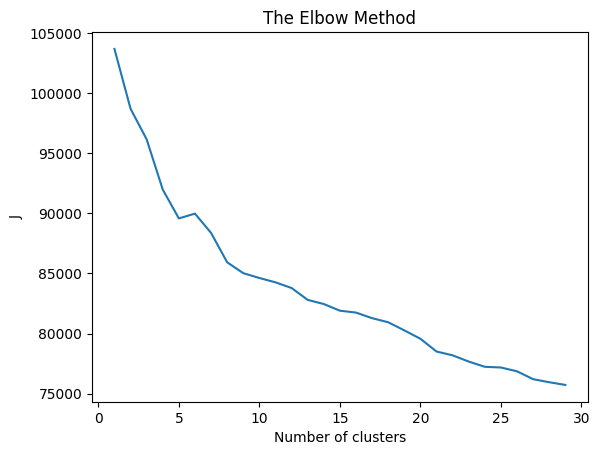

In [28]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, init='k-means++')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [29]:
#test which amount of clusters is the better fit

range_n_clusters = range(2, 11)  # test k from 2 to 10
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.1032
k=3, Silhouette Score=0.0412
k=4, Silhouette Score=0.0415
k=5, Silhouette Score=0.0422
k=6, Silhouette Score=0.0416
k=7, Silhouette Score=0.0406
k=8, Silhouette Score=0.0307
k=9, Silhouette Score=0.0275
k=10, Silhouette Score=0.0311
Best k: 2


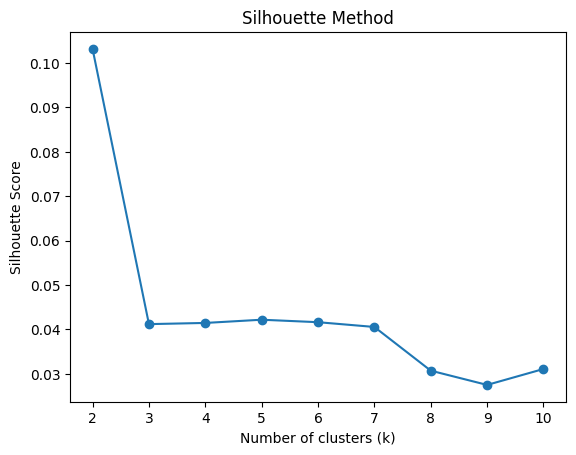

In [30]:
import matplotlib.pyplot as plt

plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [31]:
#implement kmeans algorithm with 2 to 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)
#add column for clusters
#add to original before feature scaling
data_cluster = org_X
data_cluster['Cluster_2']= kmeans_2.labels_
data_cluster['Cluster_3']= kmeans_3.labels_
data_cluster['Cluster_4']= kmeans_4.labels_
#add ID to compare results
data_cluster['ID'] = df['ID']
data_cluster.head()


,ID,DestAct,NbTransf,TimePT,WalkingTimePT,WaitingTimePT,CostPT,CostCar,TimeCar,NbHousehold,...,Choice,InVehicleTime,ModeToSchool,ReportedDuration,CoderegionCAR,age,Weight,Cluster_2,Cluster_3,Cluster_4
0,10350017,2.0,4,85,23,10,12.4,3.17,32,2.0,...,1.0,52.0,3.0,255.0,1,27.0,0.000379,0,2,0
1,10350125,4.0,1,35,15,4,4.8,0.69,9,1.0,...,1.0,16.0,4.0,15.0,1,68.0,0.000289,0,1,2
2,10350125,11.0,0,11,10,0,2.2,0.13,1,1.0,...,1.0,1.0,4.0,7.0,1,68.0,0.000289,0,1,2
3,10350197,1.0,5,124,36,24,11.0,2.44,22,2.0,...,1.0,64.0,1.0,24.0,1,30.0,0.000379,0,2,2
4,10350199,4.0,4,123,21,59,9.4,2.03,19,3.0,...,1.0,43.0,5.0,20.0,1,33.0,0.000232,0,2,2


    Envir01   Envir05   Mobil01   Mobil04   Mobil08   Mobil13   Mobil15  \
0  0.201357  1.332626  0.757689  0.701074 -1.120024  0.696126  1.077607   
1  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
2  0.887520  0.372702 -0.092074 -0.264947 -0.290307 -0.343955  0.065136   
3 -0.484806  0.372702 -0.941836  0.701074 -1.120024  0.696126  1.077607   
4  0.887520  1.332626 -1.791599 -0.264947 -1.120024  0.696126 -0.947334   

    Mobil23 ResidCh05 ResidCh07  LifSty02  LifSty06  LifSty08  LifSty11  
0  0.723599 -0.636603   0.84688  0.076336  1.614504  0.813357  0.162965  
1 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
2 -0.289211 -0.636603  -0.17677  0.966258 -0.659662 -0.204488 -0.768564  
3  1.736409 -0.636603   0.84688 -0.813585  0.098393 -3.258025  1.094494  
4 -0.289211 -0.636603   0.84688  0.076336 -0.659662  0.813357 -0.768564  


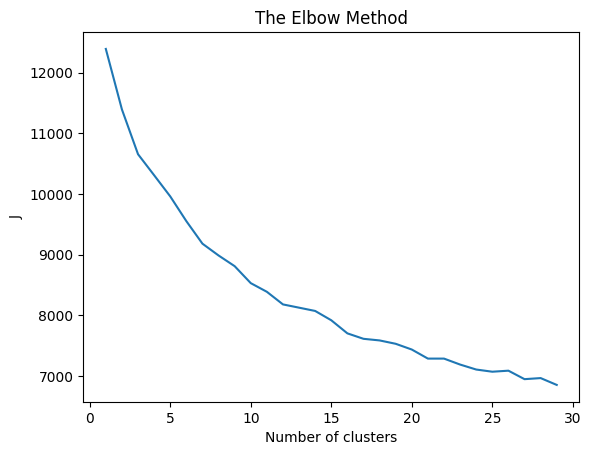

In [32]:
#check if attitudes gives better clusters
#DATA PROCESSING
X = attitude_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 
X.columns =  [attitudes] #attitudes to predict clusters
org_X_attitude = X.dropna() # to keep the version before feature scaling

# Feature scaling 
X = (X - X.mean()) / X.std()
X = X.dropna()
print(X.head()) # Prints the first 5 rows of the DataFrame
#decide on number of clusters using Elbow method


wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [33]:
#test which amount of clusters is the better fit

range_n_clusters = range(2, 11)  # test k from 2 to 10
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=1, init="k-means++").fit(X)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Best k
best_k = range_n_clusters[scores.index(max(scores))]
print("Best k:", best_k)

k=2, Silhouette Score=0.0901
k=3, Silhouette Score=0.0753
k=4, Silhouette Score=0.0637
k=5, Silhouette Score=0.0625
k=6, Silhouette Score=0.0677
k=7, Silhouette Score=0.0718
k=8, Silhouette Score=0.0693
k=9, Silhouette Score=0.0718
k=10, Silhouette Score=0.0724
Best k: 2


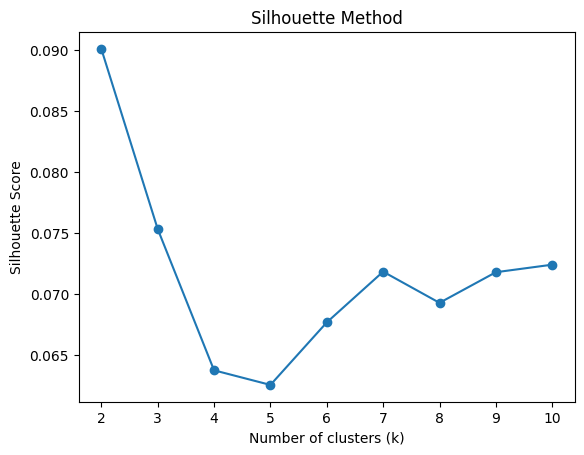

In [34]:
plt.plot(range_n_clusters, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [35]:
#implement kmeans algorithm with 4 clusters based on the outcome of the elbow method and silhouette score
kmeans_2 = KMeans(n_clusters=2, random_state=1, init="k-means++").fit(X)
kmeans_3 = KMeans(n_clusters=3, random_state=1, init="k-means++").fit(X)
kmeans_4 = KMeans(n_clusters=4, random_state=1, init="k-means++").fit(X)
#add column for clusters
#add to original before feature scaling
data_cluster_attitude = org_X_attitude
data_cluster_attitude['Cluster_2']= kmeans_2.labels_
data_cluster_attitude['Cluster_3']= kmeans_3.labels_
data_cluster_attitude['Cluster_4']= kmeans_4.labels_
data_cluster_attitude.head()

,Envir01,Envir05,Mobil01,Mobil04,Mobil08,Mobil13,Mobil15,Mobil23,ResidCh05,ResidCh07,LifSty02,LifSty06,LifSty08,LifSty11,Cluster_2,Cluster_3,Cluster_4
0,3.0,5.0,5.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,3.0,5.0,5.0,3.0,0,0,2
1,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4.0,1.0,4.0,4.0,2.0,4.0,2.0,0,0,0
2,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4.0,1.0,4.0,4.0,2.0,4.0,2.0,0,0,0
3,2.0,4.0,3.0,5.0,1.0,5.0,5.0,6.0,1.0,5.0,2.0,3.0,1.0,4.0,0,1,3
4,4.0,5.0,2.0,4.0,1.0,5.0,3.0,4.0,1.0,5.0,3.0,2.0,5.0,2.0,0,0,0


In [36]:
data_cluster_attitude.columns = [col[0] for col in data_cluster_attitude.columns]

Centroids are: [[-0.08918036  0.38134995 -0.60499332 -0.87414949 -0.34263156 -0.15655255
  -0.80139262  0.13051205 -0.19165075  0.16444641 -0.08400982 -0.25673185
   0.2631706  -0.44966209]
 [-0.64595001 -0.18725386  0.51306033 -0.03076016 -0.31545002  0.08941252
  -0.32604549  0.42435959 -0.41210423  0.38933921  0.59545712 -0.0451779
   0.42009887  0.58638717]
 [ 1.07840713  0.72635831 -0.14957632  0.62844076 -0.45874577  0.47716198
   0.68936645  0.32761307 -0.32466797  0.28502674  0.04957181  0.02999722
   0.40009678  0.09992919]
 [ 0.02235804 -0.16986392  0.10497279  0.21106328 -0.25423247  0.10825457
   0.12383033 -2.46161443 -0.04965304  0.09026887  0.16661823 -0.37401813
   0.25280476 -0.16104505]
 [-0.44444321 -0.46017351 -0.49196184  0.27488819  0.44179562  0.09960939
   0.28847551 -0.31899943  0.01708406 -0.74880997  0.08942344  1.61450394
   0.18468808 -0.04251932]
 [-0.6362962  -0.47502337 -0.00378658  0.04869611  0.05451011  0.26388497
  -0.28988582  0.34215101 -0.25174816

KeyError: 'Key length (2) exceeds index depth (1)'

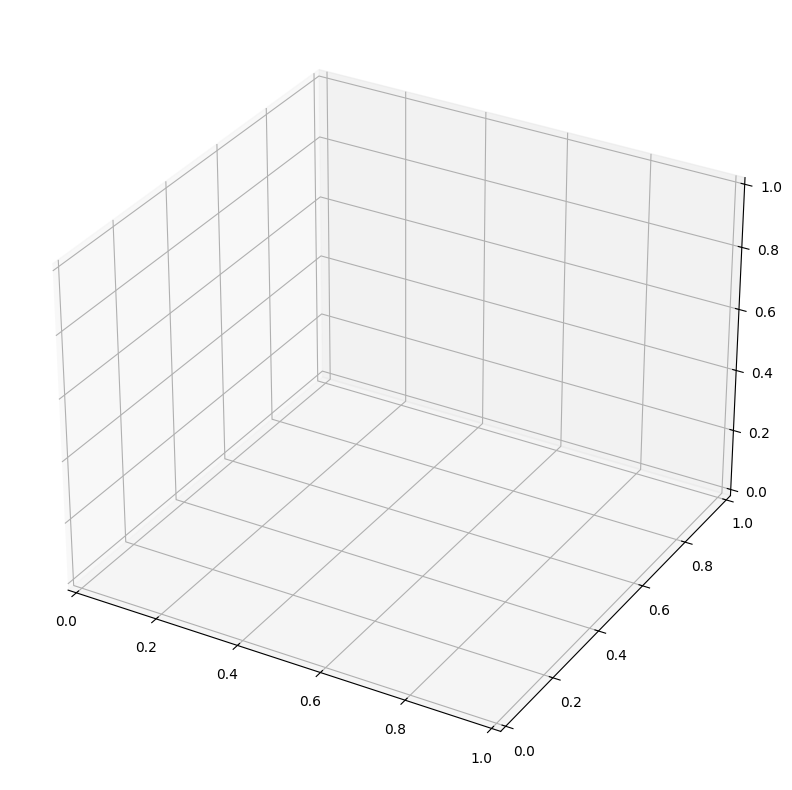

In [37]:
##still to be updated

# plot clusters in 3d 
#labels = kmeans.predict(X)                      # Getting the cluster labels
centroids = kmeans.cluster_centers_             # Centroid values
print("Centroids are:", centroids)              # From sci-kit learn

#plot
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

x = np.array(labels==0)
y = np.array(labels==1)
z = np.array(labels==2)


ax.scatter(X[x][:, 0], X[x][:, 1], X[x][:, 2], color='red')
ax.scatter(X[y][:, 0], X[y][:, 1], X[y][:, 2], color='blue')
ax.scatter(X[z][:, 0], X[z][:, 1], X[z][:, 2], color='yellow')
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            marker='x', s=169, linewidths=10,
            color='black', zorder=50)

## SOURCE: https://stackoverflow.com/questions/64987810/3d-plotting-of-a-dataset-that-uses-k-means

